<a href="https://colab.research.google.com/github/Abhinavks2006/GenerativeAI_Internship/blob/main/day_6_brain_tumour.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [41]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

In [42]:
zip_path = "archive (21).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Dataset Extracted Successfully")

Dataset Extracted Successfully


In [43]:
dataset_path = "dataset/brain_tumor_dataset"

In [44]:
yes_count = len(os.listdir(os.path.join(dataset_path, "yes")))
no_count = len(os.listdir(os.path.join(dataset_path, "no")))

print("Tumor Images :", yes_count)
print("No Tumor Images :", no_count)

Tumor Images : 155
No Tumor Images : 98


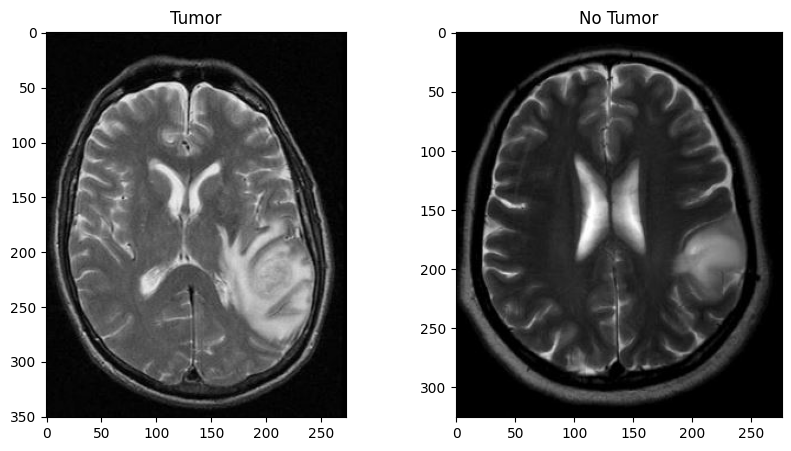

In [45]:
import cv2

plt.figure(figsize=(10,5))

tumor_img = os.listdir(os.path.join(dataset_path,"yes"))[0]
normal_img = os.listdir(os.path.join(dataset_path,"no"))[0]

img1 = cv2.imread(os.path.join(dataset_path,"yes",tumor_img))
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

img2 = cv2.imread(os.path.join(dataset_path,"no",normal_img))
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("Tumor")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("No Tumor")

plt.show()

In [46]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='training'
)

val_data = datagen.flow_from_directory(
    dataset_path,
    target_size=(128,128),
    batch_size=32,
    class_mode='binary',
    subset='validation'
)

Found 203 images belonging to 2 classes.
Found 50 images belonging to 2 classes.


In [47]:
print(train_data.class_indices)

{'no': 0, 'yes': 1}


In [48]:
model = Sequential()

# Layer 1
model.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 2
model.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Layer 3
model.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

model.add(MaxPooling2D(pool_size=(2,2)))

# Flatten
model.add(Flatten())

# Dense Layers
model.add(Dense(128, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(1, activation='sigmoid'))

In [49]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [50]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [51]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [52]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=20,
    callbacks=[early_stop]
)

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 18s 2s/step - accuracy: 0.6059 - loss: 0.8050 - val_accuracy: 0.7600 - val_loss: 0.5686
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.7685 - loss: 0.5570 - val_accuracy: 0.7200 - val_loss: 0.5614
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.7833 - loss: 0.5128 - val_accuracy: 0.7400 - val_loss: 0.5438
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 898ms/step - accuracy: 0.8227 - loss: 0.5008 - val_accuracy: 0.7600 - val_loss: 0.5362
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8374 - loss: 0.4207 - val_accuracy: 0.7600 - val_loss: 0.6124
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 910ms/step - accuracy: 0.8571 - loss: 0.3704 - val_accuracy: 0.7200 - val_loss: 0.5907
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.8571 - loss: 0.3784 - val_accuracy: 0.8000 - val_loss: 0.5356
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 907ms/step - accuracy: 0.8768 - loss: 0.3302 - val_accuracy: 0.7400 - val_loss: 0.5372
Epoch

In [53]:
loss, accuracy = model.evaluate(val_data)

print("Validation Accuracy :", accuracy)

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 264ms/step - accuracy: 0.8000 - loss: 0.4471
Validation Accuracy : 0.800000011920929


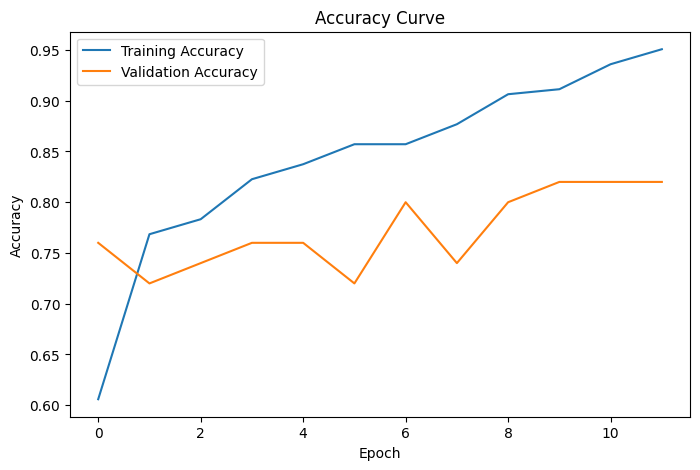

In [54]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Training Accuracy",
    "Validation Accuracy"
])

plt.show()

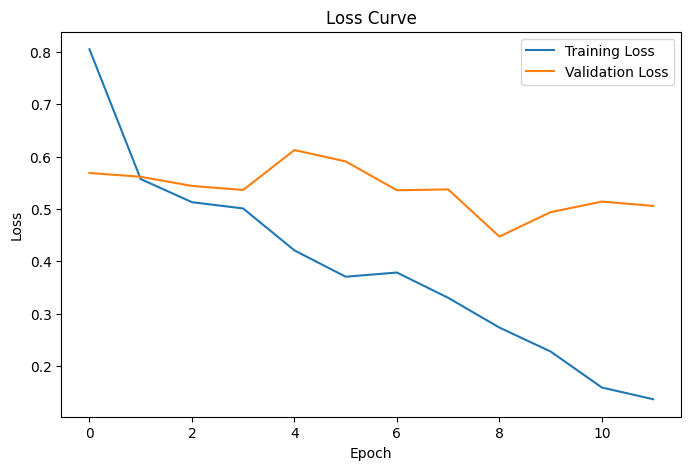

In [55]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Training Loss",
    "Validation Loss"
])

plt.show()

In [56]:
model.save("brain_tumor_cnn.h5")

print("Model Saved")

Model Saved


In [59]:
from tensorflow.keras.preprocessing import image
import os # Added to use os.path.join

# Updated img_path to point to an existing image in the dataset
# Using 'N22.JPG' from the 'no' tumor category as an example
# Make sure 'dataset_path' variable is defined in a previous cell or define it here
# For this notebook, dataset_path = "dataset/brain_tumor_dataset"
img_path = os.path.join("dataset", "brain_tumor_dataset", "no", "N22.JPG")

img = image.load_img(
    img_path,
    target_size=(128,128)
)

img_array = image.img_to_array(img)

img_array = img_array/255.0

img_array = np.expand_dims(
    img_array,
    axis=0
)

prediction = model.predict(img_array)

print(prediction)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
[[0.36582887]]


In [60]:
if prediction[0][0] > 0.5:
    print("Brain Tumor Detected")
else:
    print("No Brain Tumor")

No Brain Tumor


In [61]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import MaxPooling2D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

In [62]:
dataset_path = "dataset/brain_tumor_dataset"

images = []
labels = []

In [63]:
tumor_folder = os.path.join(dataset_path,"yes")

for img_name in os.listdir(tumor_folder):

    img_path = os.path.join(
        tumor_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(1)

In [64]:
normal_folder = os.path.join(dataset_path,"no")

for img_name in os.listdir(normal_folder):

    img_path = os.path.join(
        normal_folder,
        img_name
    )

    img = cv2.imread(img_path)

    img = cv2.resize(
        img,
        (128,128)
    )

    images.append(img)
    labels.append(0)

In [65]:
X = np.array(images)

y = np.array(labels)

print(X.shape)
print(y.shape)

(253, 128, 128, 3)
(253,)


In [66]:
X = X / 255.0

In [67]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [68]:
X_train_ml = X_train.reshape(
    X_train.shape[0],
    -1
)

X_test_ml = X_test.reshape(
    X_test.shape[0],
    -1
)

print(X_train_ml.shape)

(202, 49152)


In [69]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(
    X_train_ml,
    y_train
)

RandomForestClassifier(random_state=42)

In [70]:
y_pred_ml = rf.predict(
    X_test_ml
)

In [71]:
ml_accuracy = accuracy_score(
    y_test,
    y_pred_ml
)

print(
    "Machine Learning Accuracy:",
    ml_accuracy
)

Machine Learning Accuracy: 0.8235294117647058


In [72]:
cnn = Sequential()

cnn.add(
    Conv2D(
        32,
        (3,3),
        activation='relu',
        input_shape=(128,128,3)
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        64,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(
    Conv2D(
        128,
        (3,3),
        activation='relu'
    )
)

cnn.add(
    MaxPooling2D((2,2))
)

cnn.add(Flatten())

cnn.add(Dense(
    128,
    activation='relu'
))

cnn.add(
    Dropout(0.5)
)

cnn.add(
    Dense(
        1,
        activation='sigmoid'
    )
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [73]:
cnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [74]:
history = cnn.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32
)

Epoch 1/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 885ms/step - accuracy: 0.6522 - loss: 0.6900 - val_accuracy: 0.8537 - val_loss: 0.4260
Epoch 2/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.7702 - loss: 0.5202 - val_accuracy: 0.5366 - val_loss: 0.8000
Epoch 3/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 9s 842ms/step - accuracy: 0.7391 - loss: 0.5751 - val_accuracy: 0.8293 - val_loss: 0.3922
Epoch 4/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.7764 - loss: 0.4793 - val_accuracy: 0.8537 - val_loss: 0.4020
Epoch 5/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 8s 917ms/step - accuracy: 0.7950 - loss: 0.4642 - val_accuracy: 0.8293 - val_loss: 0.3871
Epoch 6/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 832ms/step - accuracy: 0.8137 - loss: 0.4163 - val_accuracy: 0.8293 - val_loss: 0.3901
Epoch 7/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 11s 1s/step - accuracy: 0.8323 - loss: 0.3944 - val_accuracy: 0.7805 - val_loss: 0.4294
Epoch 8/10
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 771ms/step - accuracy: 0.8509 - loss: 0.3550 - val_accuracy: 0.8293 - val_loss: 0.3045


In [75]:
loss, dl_accuracy = cnn.evaluate(
    X_test,
    y_test
)

print(
    "Deep Learning Accuracy:",
    dl_accuracy
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step - accuracy: 0.8039 - loss: 0.5479
Deep Learning Accuracy: 0.8039215803146362


In [76]:
print("\nMODEL COMPARISON")
print("--------------------------")
print("Random Forest :", ml_accuracy)
print("CNN           :", dl_accuracy)


MODEL COMPARISON
--------------------------
Random Forest : 0.8235294117647058
CNN           : 0.8039215803146362


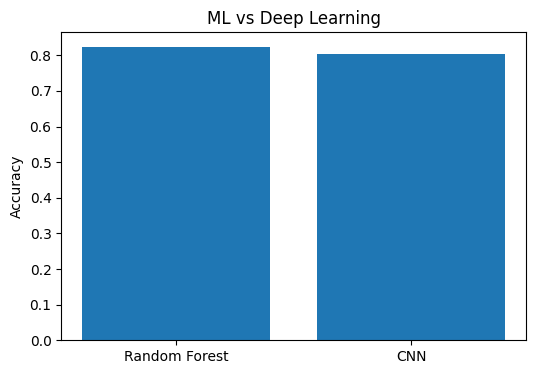

In [77]:
models = [
    "Random Forest",
    "CNN"
]

scores = [
    ml_accuracy,
    dl_accuracy
]

plt.figure(figsize=(6,4))

plt.bar(
    models,
    scores
)

plt.ylabel("Accuracy")
plt.title("ML vs Deep Learning")

plt.show()